In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("Sample - Superstore.csv",encoding="latin1")

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.shape

(9994, 21)

In [18]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [20]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Dataset Observations

The dataset contains transactional retail information including customer,
product, location, sales, quantity, discount and profit information.

The dataset will be checked for missing values, duplicate records,
incorrect data types and inconsistencies before performing analysis.

In [22]:
#Checking duplicate values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [24]:
# Checking duplicate rows
df.duplicated().sum()

0

In [26]:
#Convertion of dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [28]:
#Create additional date columns
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [30]:
#Clean text colums
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [32]:
#Save cleaned dataset
df.to_csv("cleaned_superstore.csv", index=False)

## Numpy



In [34]:
sales_array = np.array(df["Sales"])

print("Total Sales:", np.sum(sales_array))
print("Average Sales:", np.mean(sales_array))
print("Median Sales:", np.median(sales_array))
print("Minimum Sales:", np.min(sales_array))
print("Maximum Sales:", np.max(sales_array))
print("Standard Deviation:", np.std(sales_array))

Total Sales: 2297200.8603000003
Average Sales: 229.85800083049833
Median Sales: 54.489999999999995
Minimum Sales: 0.444
Maximum Sales: 22638.48
Standard Deviation: 623.2139187650461


In [36]:
profit_array = np.array(df["Profit"])

print("Total Profit:", np.sum(profit_array))
print("Average Profit:", np.mean(profit_array))
print("Median Profit:", np.median(profit_array))

Total Profit: 286397.0217
Average Profit: 28.65689630778467
Median Profit: 8.6665


## Exploratory Data Analysis

In [38]:
#Descriptive Statistics
df[["Sales", "Quantity", "Discount", "Profit"]].describe()
print("Mean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Mode Sales:", df["Sales"].mode()[0])

print("Variance:", df["Sales"].var())
print("Standard Deviation:", df["Sales"].std())

Mean Sales: 229.85800083049833
Median Sales: 54.489999999999995
Mode Sales: 12.96
Variance: 388434.45530807687
Standard Deviation: 623.2451005086818


In [40]:
#Total Business KPIs
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


In [42]:
#Category Analysis
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

category_analysis

,Sales,Profit,Quantity
Category,,,
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906
Technology,836154.0330,145454.9481,6939


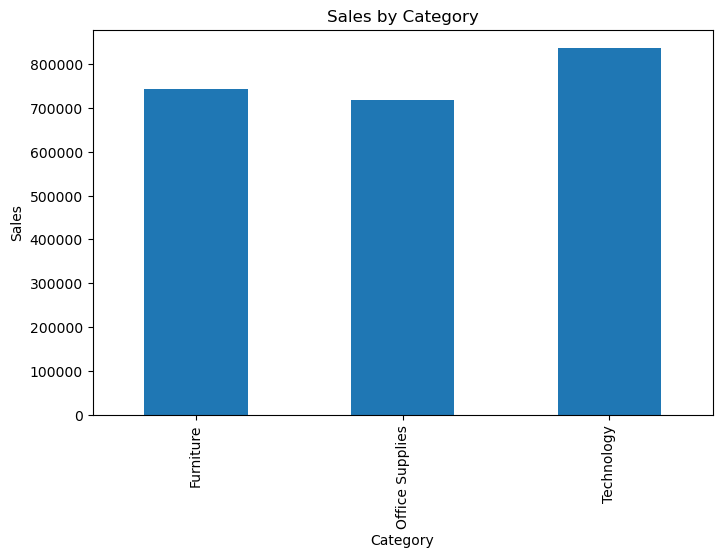

In [44]:
#Sales by Category Chart
category_analysis["Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

## Observations
Technology generated the highest sales.

Technology generated the highest profit.

Furniture generated high sales but comparatively low profit.

Office Supplies generated lower sales than Technology but strong profitability.

## Product Analysis

In [49]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

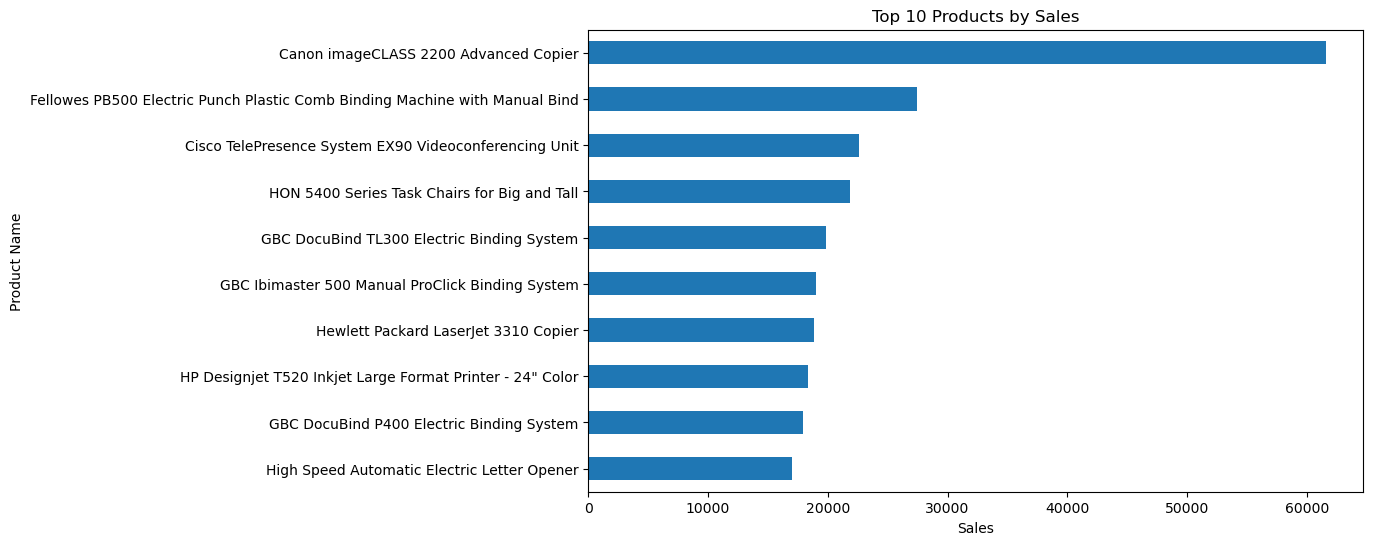

In [51]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

## Observation

Canon imageCLASS 2200 Advanced Copier generated the highest revenue ($61,599.82).

Several office and binding equipment products appear in the top 10.

High-value technology and business equipment contribute significantly to total sales.

Premium products account for a large share of revenue.

## Regional Analysis

In [55]:
regional_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Sales", ascending=False)

regional_analysis

,Sales,Profit,Orders
Region,,,
West,725457.8245,108418.4489,1611
East,678781.2400,91522.7800,1401
Central,501239.8908,39706.3625,1175
South,391721.9050,46749.4303,822


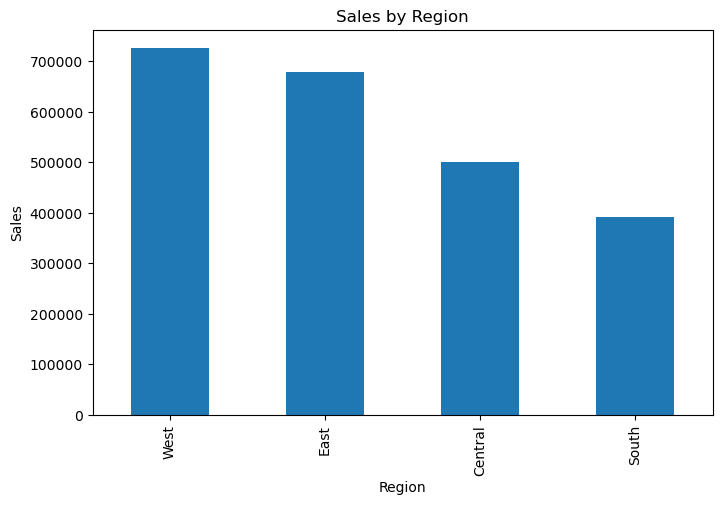

In [57]:
# region sales chart
regional_analysis["Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.show()

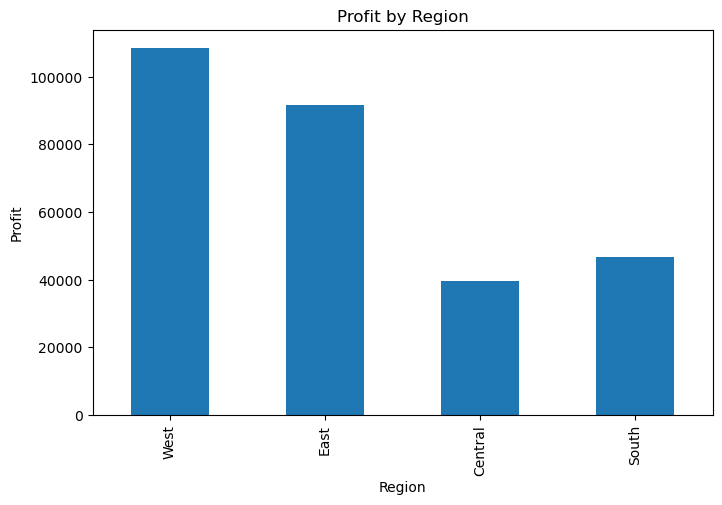

In [59]:
#Region Profit Chart
regional_analysis["Profit"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.show()

## Regional Analysis Insights
West region generated the highest sales.

West region also generated the highest profit.

East region is the second strongest performing region.

South generated lower sales than Central but achieved higher profit.

Central region may require further investigation to improve profitability.ility.

## Monthly sales trend Analysis

In [70]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [72]:
#monthly sales
monthly_sales = (
    df.groupby("Year-Month")["Sales"]
    .sum()
)

monthly_sales

Year-Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


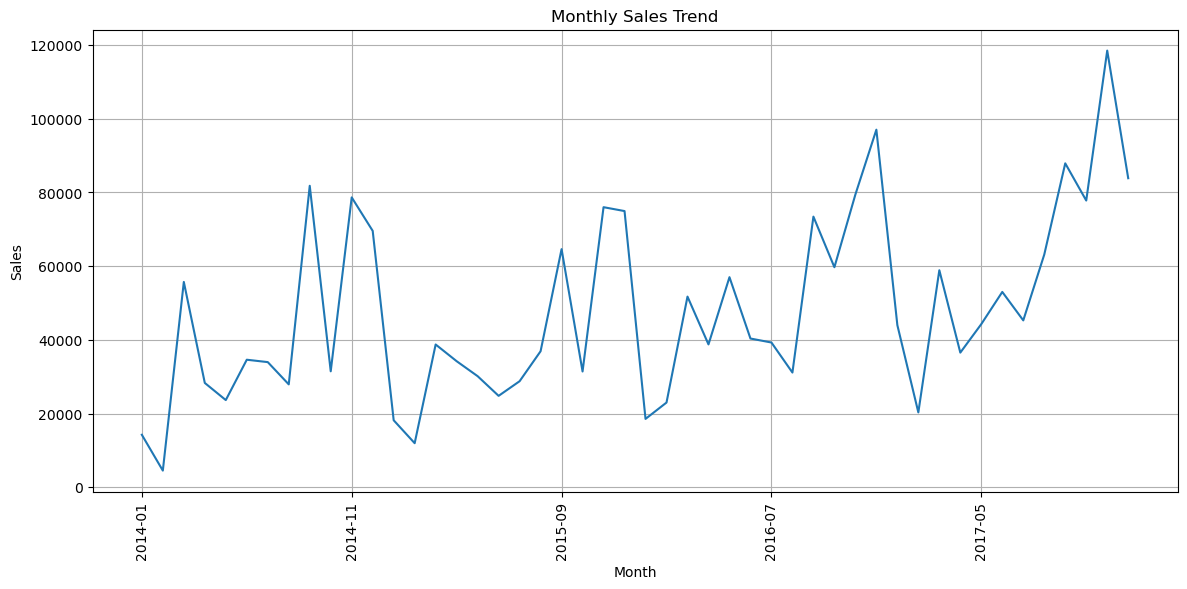

In [74]:
# monthly sale s chart
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid()

plt.show()

In [76]:
#Best Sales month
monthly_sales.idxmax(), monthly_sales.max()

('2017-11', 118447.825)

In [80]:
#Lowest sales month
monthly_sales.idxmin(), monthly_sales.min()

('2014-02', 4519.892)

## Monthly Sales Trend Insights

The highest sales were recorded in November 2017.

The lowest sales were recorded in February 2014.

Sales generally increased over time.

Peak sales periods may be associated with seasonal demand and promotional activities.

## Coustemer Analysis

In [86]:
#Top customers by sales
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

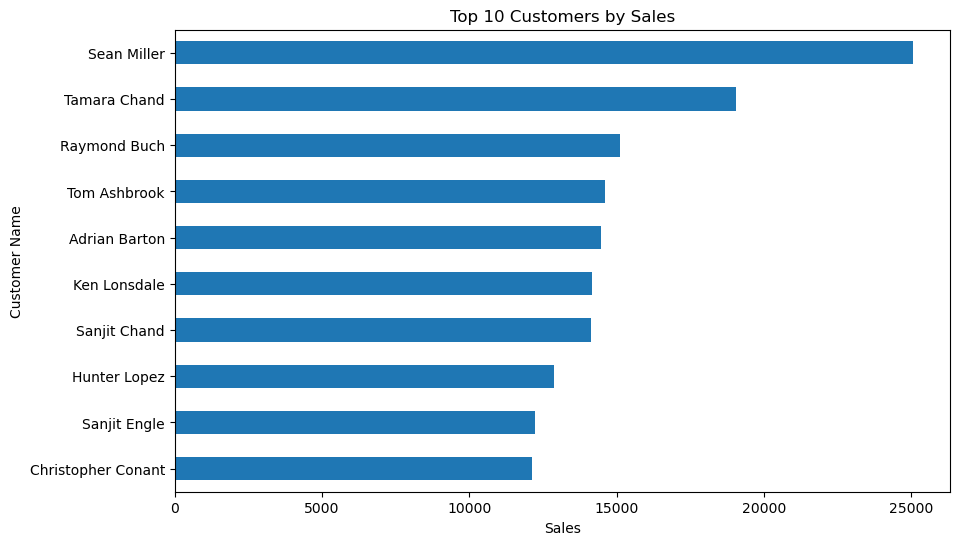

In [88]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.show()

In [90]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head()

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

## Underperforming categories

In [93]:
category_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

category_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [95]:
#Loss making sub-categories
loss_categories = category_profit[category_profit < 0]

loss_categories

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64

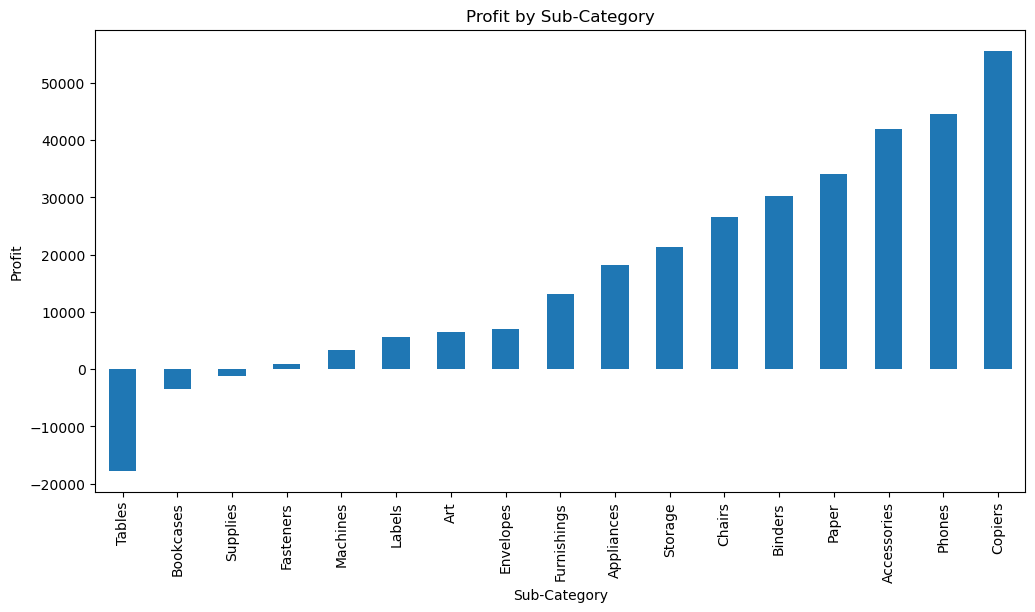

In [97]:
#Profit by subcategory chart
category_profit.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Profit by Sub-Category")
plt.ylabel("Profit")
plt.show()

## Underperforming Categories

The following sub-categories generated overall losses:

1. Tables (-17,725.48)
2. Bookcases (-3,472.56)
3. Supplies (-1,189.10)

Although these products generated sales, they reduced overall profitability.
Possible reasons include excessive discounting, high shipping costs,
or low profit margins.

## Correlation analysis and heat map

In [101]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation = df[numeric_columns].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


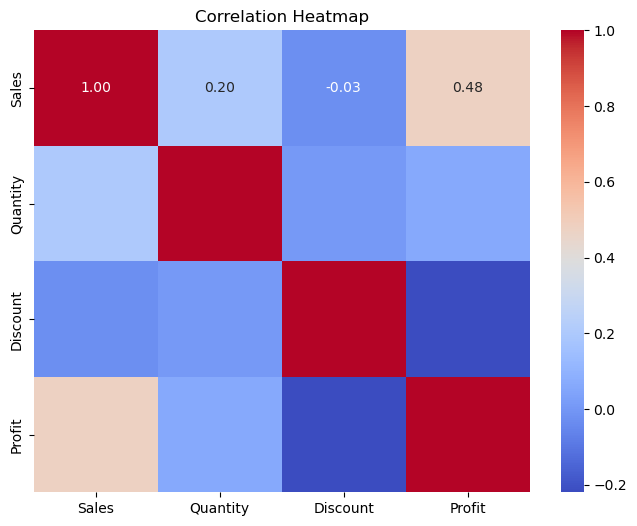

In [103]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [105]:
#Discount vs profit analysis
discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
)

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

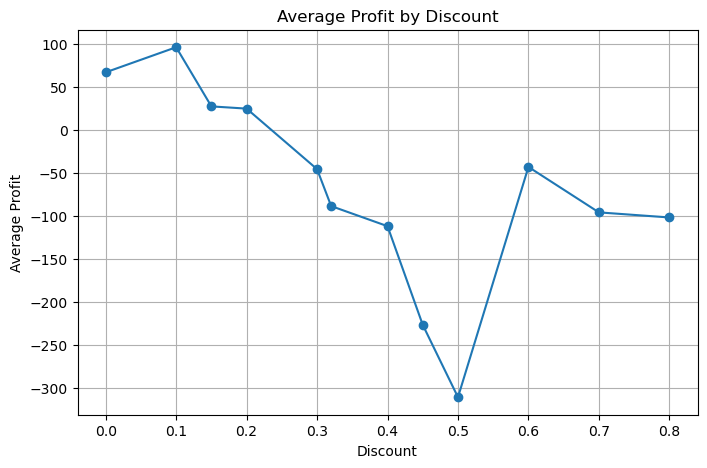

In [107]:
discount_profit.plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.grid()

plt.show()

## Distribution Analysis

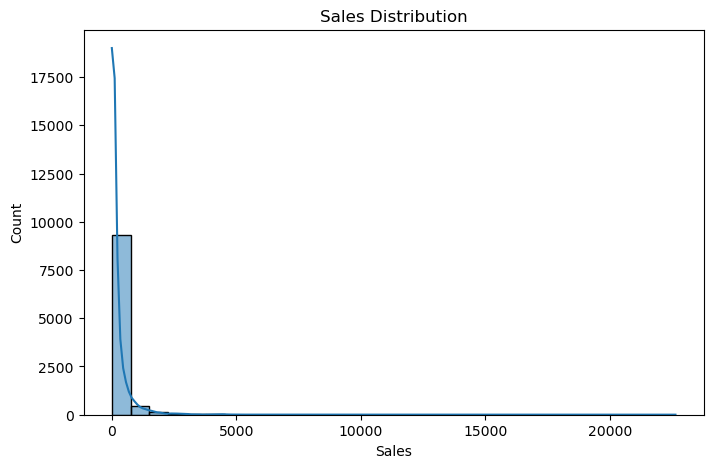

In [110]:
#Sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")

plt.show()

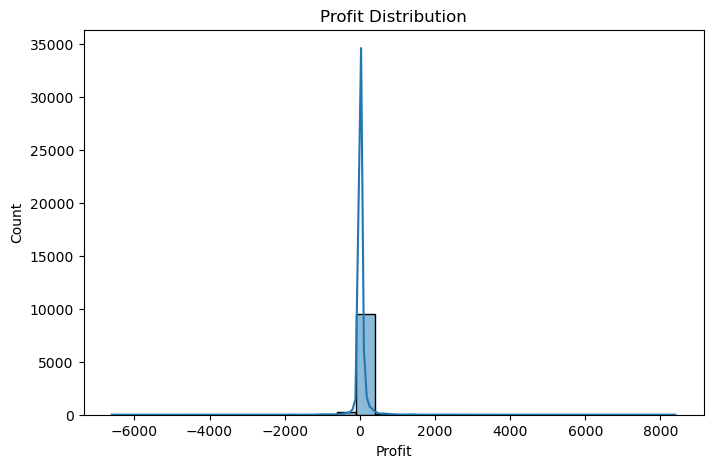

In [112]:
#Profit distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")

plt.show()

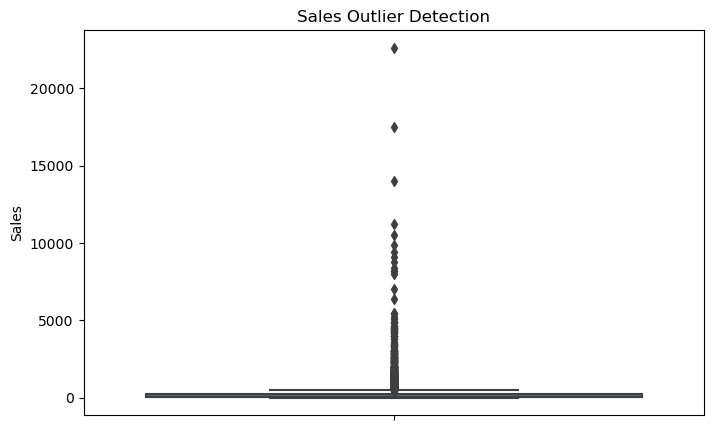

In [119]:
# Box plot
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Sales"])

plt.title("Sales Outlier Detection")

plt.show()